1. Sequence Length and Generation Performance

4.1 Key Takeaways

Let's break down what we observed and why it happened.

Observation

A longer input prompt leads to higher end-to-end latency (it takes more time) and therefore lower throughput (fewer tokens per second), even though the model is generating the same number of new tokens in both cases.

This slowdown happens on both CPU and GPU.

The "Why": Self-Attention

This slowdown is a fundamental characteristic of the Transformer architecture.

To generate each subsequent token, the model must perform a self-attention operation.

In this operation, the new token must "attend to" (or look at) all the previous tokens. This includes the original prompt and all the tokens it has already generated.

- Short Prompt: To generate token #11, the model attends to the 5 prompt tokens + 10 generated tokens = 15 tokens.
- Long Prompt: To generate token #11, the model attends to the 172 prompt tokens + 10 generated tokens = ~182 tokens.

Implication

The cost of generation is not just about the number of tokens you create; it's heavily influenced by the total context length (prompt + generation).

This is why handling long contexts efficiently is a major area of research and engineering.


2. Profile Baseline LLM


--- Summary of Baseline Metrics ---

--- CPU Metrics ---
Model Memory (Approx. Parameters): 1.322 GB
E2E Latency:                     18.6154 s
Tokens/sec (single-stream):      2.69 tokens/s

--- GPU Metrics ---
Model Memory (Allocated):        1.345 GB
Model Memory (Reserved):         1.348 GB
E2E Latency (CUDA Event):        1.3128 s
Tokens/sec (single-stream):      38.09 tokens/s

--- Performance Speedup ---
Latency Speedup (CPU / GPU):     14.18x
Throughput Speedup (GPU / CPU):  14.18x


4.2. GPU Warm-up and Accurate Timing

Warm-up: The first time you run an operation on a GPU, it needs to compile underlying CUDA kernels. This adds significant overhead. We perform a "warm-up" run with a small number of tokens to get this compilation out of the way, ensuring our actual benchmark is more accurate.

Accurate Timing: GPU operations are asynchronous. The CPU can issue a command and move on before the GPU has finished. Using time.time() would be inaccurate. Instead, we use torch.cuda.Event to record timestamps directly on the GPU's execution stream, and torch.cuda.synchronize() to ensure all operations are complete before we stop the timer.

4.1. GPU Memory Usage

First, we move the model to the GPU and measure its memory footprint. On GPUs, we look at two metrics:
- Memory Allocated: The memory actively used by tensors.
- Memory Reserved: The total memory pool reserved by the PyTorch caching allocator. This is often larger than the allocated memory.

Step 6: Conclusion & Key Takeaways

In this demonstration, we successfully established a performance baseline for the gpt2-medium model.

Key Takeaways:
- Profiling is Essential: We now have concrete numbers for latency, throughput, and memory. This is the starting point for any optimization effort.
- GPUs Provide Massive Speedups: As expected, the GPU outperformed the CPU by a significant margin (~14x in this case), highlighting its necessity for efficient LLM inference.
- Accurate Measurement Matters: We saw the importance of using the right tools (torch.cuda.Event) and techniques (warm-up runs) to get reliable performance data, especially on asynchronous hardware like GPUs.
- Memory Footprint is Similar: The model's parameter memory is roughly the same on CPU and GPU, but GPU memory management is more complex (allocated vs. reserved).

With this baseline, we are now ready to explore various optimization techniques in future lessons to see how we can improve these metrics even further.


3. Profiling of LLM


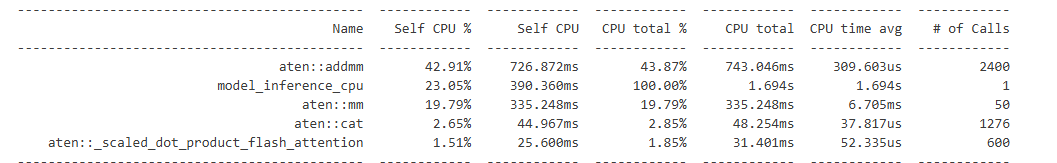

Analyzing the CPU Profile

After running the cell above, look at the output table.
- Wall Clock Time: This is the total real-world time it took to run the generation.
- aten::addmm: You'll likely see this operation at or near the top. It stands for ADD Matrix-Matrix multiplication and is the core of the linear layers in the Transformer model. This is where most of the heavy lifting happens.
- aten::mm: General matrix multiplication.
- aten::_scaled_dot_product_flash_attention: This indicates that an optimized attention mechanism is being used, even on the CPU.

Step 6: Profiling Model Inference on GPU

Now, let's see how much a GPU can speed things up. The process is similar, but with a few key differences for GPU profiling:

1. Check for GPU: We first check if torch.cuda.is_available().
2. Move to GPU: We move the model and input tensors to the "cuda" device.
3. Warm-up Run: The first time you run an operation on a GPU, it has to perform setup tasks (like loading CUDA kernels) that take extra time. We'll do a "warm-up" run first so these one-time costs don't pollute our actual measurement.
4. Synchronize: GPU operations are asynchronous. The CPU gives a command to the GPU and immediately moves on. To get accurate timing, we must use torch.cuda.synchronize() to make the CPU wait for the GPU to finish its work.
5. Profile: We include ProfilerActivity.CUDA in the profiler's activities list.


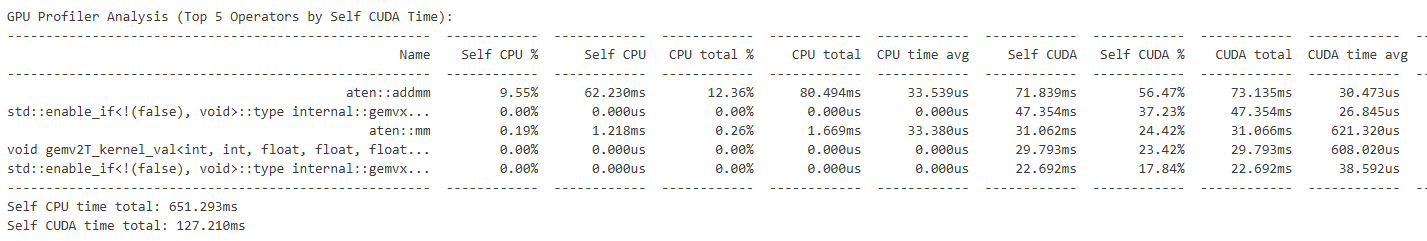

Analyzing the GPU Profile

Now, examine the GPU profiler output.
- Wall Clock Time: Compare this to the CPU time. You should see a significant speedup!
- Top Operators: The operator names will be different. Instead of aten:: operations, you will see low-level CUDA kernels. Names like gemv or gemm (General Matrix-Vector/Matrix-Matrix multiplication) are common. These are the highly-optimized functions that run on the GPU hardware.
- Self CUDA %: This column is now the most important one. It tells you the percentage of total GPU time that was spent inside a specific kernel.

Step 7: Conclusion and Key Takeaways

Congratulations! You've successfully profiled an LLM on both CPU and GPU. Let's summarize what we've learned.

1. Performance Comparison:
We observed a clear performance gain when moving from CPU to GPU. The total wall clock time for generation was significantly lower on the GPU, demonstrating the power of parallel processing for deep learning workloads.

2. Identifying Bottlenecks:
On both CPU and GPU, the profiling results pointed to the same root cause of computational load: matrix multiplications (addmm, mm on CPU; gemm/gemv kernels on GPU). This is the fundamental building block of Transformer models, and it's where most of the time is spent.

3. The Power of Profiling:
This exercise demonstrates that before you can optimize anything, you must first measure it. The PyTorch Profiler is an indispensable tool that gives you a detailed view of where your program is spending its time.

4. Next Steps:
Now that we can identify bottlenecks, we can start exploring ways to fix them. Future lessons will cover techniques like quantization, using optimized kernels like Flash Attention, and other strategies to speed up these expensive matrix multiplication operations.
